# Flexible AttentionFlexible attention patterns and implementations.

In [1]:
from probjax.nn.attention import flex_attention, dot_product_attention
from probjax.nn.nets import Transformer
import jax.numpy as jnp
import jax

from flax import nnx

In [2]:
seq_len = 256
q = jax.random.normal(jax.random.PRNGKey(0), (1,seq_len, 1, 4))
k = jax.random.normal(jax.random.PRNGKey(1), (1,seq_len, 1, 4))
v = jax.random.normal(jax.random.PRNGKey(2), (1,seq_len, 1, 4))
mask_q = jax.random.bernoulli(jax.random.PRNGKey(3), 0.9, (seq_len,))
mask = (mask_q[:,None] * mask_q[None,:]) | jnp.eye(seq_len).astype(jnp.int32)

dot_product_attention(q, k, v).mean(-1)

Array([[[-0.014],
        [ 0.036],
        [-0.098],
        [-0.069],
        [ 0.018],
        [-0.003],
        [-0.046],
        [ 0.056],
        [ 0.018],
        [ 0.028],
        [ 0.027],
        [ 0.03 ],
        [ 0.005],
        [ 0.003],
        [ 0.022],
        [ 0.048],
        [ 0.052],
        [-0.038],
        [-0.068],
        [-0.002],
        [-0.066],
        [-0.031],
        [ 0.037],
        [-0.017],
        [-0.045],
        [ 0.005],
        [ 0.035],
        [-0.005],
        [ 0.008],
        [ 0.017],
        [-0.003],
        [ 0.02 ],
        [-0.046],
        [ 0.088],
        [-0.007],
        [ 0.021],
        [ 0.026],
        [ 0.008],
        [ 0.025],
        [-0.127],
        [ 0.023],
        [-0.032],
        [ 0.029],
        [ 0.006],
        [ 0.058],
        [ 0.015],
        [-0.039],
        [ 0.004],
        [ 0.013],
        [-0.088],
        [-0.046],
        [ 0.02 ],
        [ 0.028],
        [ 0.059],
        [ 0.024],
        [ 

In [4]:
def f(x):
    return dot_product_attention(x, x, x, mask=mask).mean((-2,-1))

J = jax.jacfwd(f)(q).sum(-1).reshape(seq_len,seq_len)

In [7]:
import matplotlib.pyplot as plt

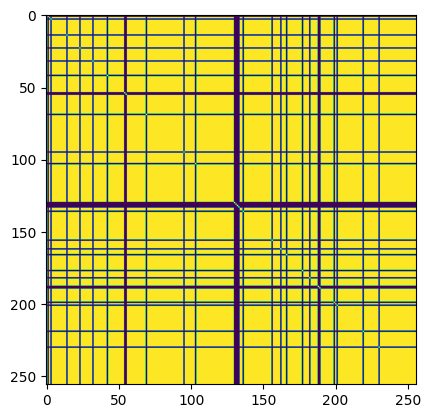

In [8]:
plt.imshow(mask)

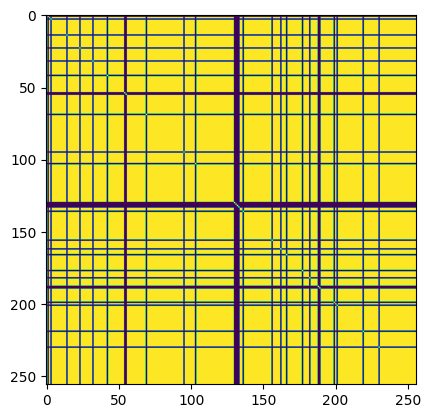

In [15]:
plt.imshow(~jnp.isclose(J, 0., atol=1e-8))

In [16]:
q.shape

(1, 256, 1, 4)

In [38]:
import numpy as np
from functools import partial

from probjax.nn.pallas_kernels import BlockSizes

def mask_fn(b_idx,h_idx, q_idx, k_idx, q_segment_ids, kv_segment_ids):
    return q_segment_ids[None, :] == kv_segment_ids[:, None]

q_segment_ids = mask_q.reshape(1,seq_len)
attn_fn = jax.jit(partial(flex_attention, mask=mask_fn, block_sizes=BlockSizes(block_q=16, block_k=16, block_q_dkv=16,
            block_kv_dkv=16,
            block_q_dq=16,
            block_kv_dq=16,)))

In [39]:
attn_fn2 = jax.jit(partial(dot_product_attention, mask=mask))

In [41]:
%%timeit
attn_fn(q, k, v, segment_ids=q_segment_ids).block_until_ready()

1.42 ms ± 8.76 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [23]:
%%timeit
attn_fn2(q, k, v, mask=mask).block_until_ready()

1.34 ms ± 13.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [42]:
def f(x):
    return flex_attention(x, x, x, mask=mask_fn, segment_ids=q_segment_ids).mean((-2,-1))

J = jax.jacrev(f)(q).sum(-1).reshape(16,16)

XlaRuntimeError: RESOURCE_EXHAUSTED: Shared memory size limit exceeded: requested 107008, available: 101376

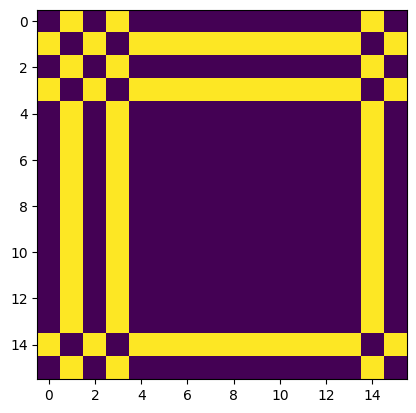

In [ ]:
plt.imshow(jnp.isclose(J, 0., atol=1e-6))

In [45]:
import matplotlib.pyplot as plt

def f(x):
    # Create query tensor from input x
    x = x[None, :, None, None]  # Shape: [1, seq_len, 1, 1]
    x = x.repeat(3, axis=2)     # Shape: [1, seq_len, 3, 1]
    x = x.repeat(4, axis=3)     # Shape: [1, seq_len, 3, 4]

    # Create causal mask where each position can only attend to previous positions
    mask = lambda b,h,q,k,*_: q[:,None] >= k[None,:]

    # Apply attention with the causal mask
    out = dot_product_attention(x, k, v, mask=mask).sum((-2,-1))[0]
    return out

# Get input values and compute jacobian
x = jnp.arange(16, dtype=jnp.float32)
jac = jax.jacrev(f)(x)

# Plot
plt.figure(figsize=(12,4))

plt.subplot(121)
plt.imshow(jac)
plt.title('Jacobian (should be lower triangular)')
plt.colorbar()

plt.subplot(122)
# Show the causal mask pattern
mask_pattern = jnp.array([[i >= j for j in range(16)] for i in range(16)])
plt.imshow(mask_pattern)
plt.title('Causal Mask Pattern (True = allowed)')
plt.colorbar()

TypeError: where requires ndarray or scalar arguments, got <class 'function'> at position 0.

In [43]:
jax.jacrev(f)(jnp.arange(16).astype(jnp.float32))

Array([[-1.658,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
         0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   , -2.135,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
         0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   , -0.933,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
         0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   , -0.309,  0.   ,  0.   ,  0.   ,  0.   ,
         0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   , -0.022,  0.   ,  0.   ,  0.   ,
         0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.097,  0.   ,  0.   ,
         0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.127,  0.   ,
         0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0

In [18]:
flex_attention(q, k, v, mask=mask_fn)

Array([[[[ 0.   ,  0.   ,  0.   ,  0.   ],
         [ 0.   ,  0.   ,  0.   ,  0.   ],
         [ 0.   ,  0.   ,  0.   ,  0.   ]],

        [[ 0.36 ,  1.284, -0.738,  1.182],
         [-0.206, -0.833,  0.623, -0.887],
         [ 0.692,  0.871,  1.497, -1.323]],

        [[ 1.308, -0.011,  0.113,  0.973],
         [-0.358,  0.112, -0.594, -1.638],
         [ 0.165,  0.361,  0.412, -1.581]],

        [[ 0.819,  0.26 , -0.594,  0.832],
         [-0.613, -0.681,  1.157, -0.164],
         [ 0.216,  0.35 ,  0.477, -1.476]],

        [[ 1.481, -0.796,  0.252,  0.308],
         [-0.219, -0.577,  0.612, -0.045],
         [ 0.214, -0.404,  0.095, -0.282]],

        [[ 0.473, -0.222, -0.352,  0.121],
         [-0.047, -0.252,  0.044, -0.243],
         [-0.024, -0.793, -0.257,  0.382]],

        [[ 1.179, -0.632,  0.177,  0.387],
         [ 0.588, -0.02 , -0.306,  0.011],
         [ 0.018, -1.645, -1.046,  0.919]],

        [[ 0.985, -0.651,  0.069,  0.383],
         [ 0.395, -0.025, -0.379, -0.034